In [1]:
import sys
import numpy as np
recommended = (3, 10)
current = sys.version_info[:2]

if current < recommended:
    print(f"You are using Python {current[0]}.{current[1]}. Python {recommended[0]}.{recommended[1]} or later is recommended.")
else:
    print(f"Python {current[0]}.{current[1]} — looks good!")

Python 3.12 — looks good!


In [2]:
%pip install --upgrade 'qiskit[visualization]>=2.5.0' qiskit-aer qiskit-ibm-runtime matplotlib
%pip install --upgrade qc-grader

Note: you may need to restart the kernel to use updated packages.
  Attempting uninstall: qc-grader
    Found existing installation: qc_grader 2026.7.2
    Uninstalling qc_grader-2026.7.2:
      Successfully uninstalled qc_grader-2026.7.2
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import platform
import shutil
import subprocess
import sys

import qc_grader
import qiskit

from qc_grader.challenges.qgss_2026 import check_progress
from qc_grader.challenges.qgss_2026.lab0 import (
    grade_lab0_ex1,
    grade_lab0_ex2,
    grade_lab0_ex3,
    grade_lab0_ex4,
)


from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import array_to_latex, plot_histogram, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

import matplotlib.pyplot as plt

print(f"Qiskit version: {qiskit.__version__}")
print(f"Grader version: {qc_grader.__version__}")

Qiskit version: 2.5.0
Grader version: 2026.7.16


In [4]:
# Paste your IBM Cloud credentials here. You only need to do this once per environment.
# After it works, you can comment these lines out so the credentials do not stay in the file.

token = "<ApiKey-60015c39-3dfe-4888-a515-84f3f1b00ade>"
instance = "<crn:v1:bluemix:public:quantum-computing:us-east:a/260c051cd3724ffbbc2d09279aafcbf1:9e873d69-edfd-4084-a612-0e9baa132ffb::>"  # looks like "crn:v1:bluemix:public:quantum-computing:..."

#QiskitRuntimeService.save_account(
#    token=token,
#    instance=instance,
#    overwrite=True,
#    set_as_default=True,
#)

# Verify
service = QiskitRuntimeService()
backends = service.backends()
print(f"Account OK. {len(backends)} backend(s) available:")
for b in backends[:5]:
    print(f"  {b.name} ({b.num_qubits} qubits)")

qiskit_runtime_service.__init__:WARNING:2026-07-16 07:41:07,216: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-07-16 07:41:07,219: Loading instance: open-instance, plan: open


Account OK. 3 backend(s) available:
  ibm_fez (156 qubits)
  ibm_marrakesh (156 qubits)
  ibm_kingston (156 qubits)


In [5]:
grade_lab0_ex1()

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-16 07:41:15,331: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


🎉 Your IBM Quantum account is properly configured!
You have successfully connected to the grading server.
You're all set to continue with the rest of the lab.
You scored 1 on this exercise.


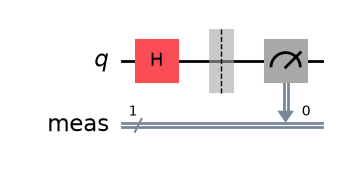

In [6]:
qc = QuantumCircuit(1)

qc.h(0)
qc.measure_all()
qc.draw("mpl")




In [7]:
#TO DO: DEFINE THE OBSERVABLE AS THE SINGLE-QUBIT Z OPERATOR
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
import numpy as np

observable = SparsePauliOp("Z")

print(f"Observable: {observable}")

SparsePauliOp(["II", "XZ"], np.array(ParameterVector("a", 2)))



Observable: SparsePauliOp(['Z'],
              coeffs=[1.+0.j])


SparsePauliOp(['II', 'XZ'],
              coeffs=[<qiskit._accelerate.circuit.ParameterExpression object at 0x74a618d46790>,
 <qiskit._accelerate.circuit.ParameterExpression object at 0x74a618d467f0>])

In [8]:
backend = AerSimulator()
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

# Sampler requires measurements in the circuit
qc_meas = qc.copy()
qc_meas.measure_all()
isa_qc_meas = pm.run(qc_meas)

# Estimator takes the circuit without measurements and evaluates the observable separately
isa_qc = pm.run(qc)

# Apply the same layout to the observable so qubit indices match the transpiled circuit
isa_observable = observable.apply_layout(isa_qc.layout)

print("Transpiled circuit and observable ready.")

Transpiled circuit and observable ready.


In [9]:
sampler = Sampler(mode=backend)
sampler_result = sampler.run([isa_qc_meas], shots=1000).result()
counts = sampler_result[0].data.meas.get_counts()

print("Sampler counts:", counts)

Sampler counts: {'1': 475, '0': 525}


In [10]:
grade_lab0_ex2(counts)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-16 07:41:21,099: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your answer is correct. 525:475 — looks like 50/50 superposition from the Hadamard gate.
You scored 1 on this exercise.


In [11]:
# Run Estimator — circuit WITHOUT measurements + observable
estimator = Estimator(mode=backend)
estimator_result = estimator.run([(isa_qc, isa_observable)]).result()
exp_val = estimator_result[0].data.evs

print(f"⟨Z⟩ = {exp_val:.4f}")

⟨Z⟩ = -0.0200


In [12]:
grade_lab0_ex3(exp_val)

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-16 07:41:25,752: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your answer is correct. ⟨Z⟩ = -0.0200 ≈ 0
You scored 1 on this exercise.


Sampler counts: {'1': 475, '0': 525}


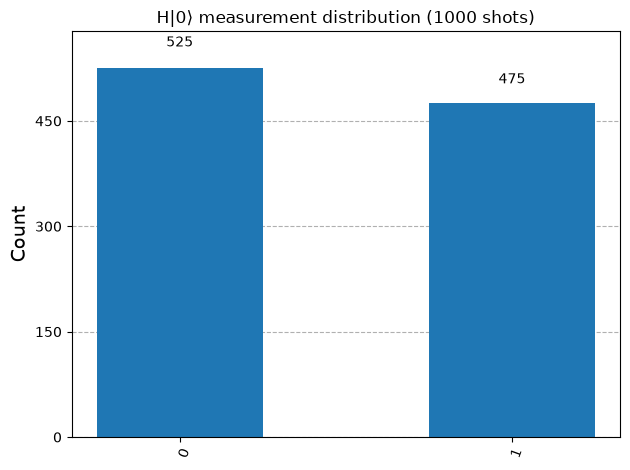


Estimator ⟨Z⟩ = -0.0200 ± 0.0156


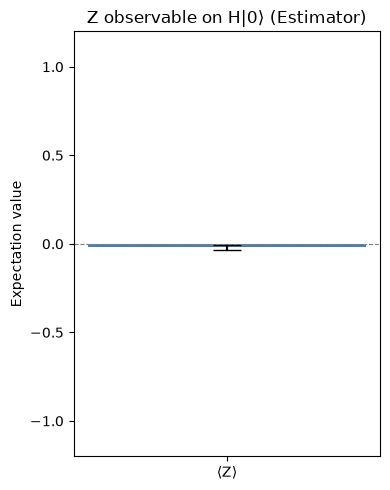

In [13]:
# Sampler results
print(f"Sampler counts: {counts}")
display(plot_histogram(counts, title="H|0⟩ measurement distribution (1000 shots)"))

# Estimator results
ev = estimator_result[0].data.evs.item()
std = estimator_result[0].data.stds.item()
print(f"\nEstimator ⟨Z⟩ = {ev:.4f} ± {std:.4f}")

fig, ax = plt.subplots(figsize=(4, 5))
ax.bar(["⟨Z⟩"], [ev], yerr=[std], capsize=10, color="steelblue", width=0.4)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylim(-1.2, 1.2)
ax.set_ylabel("Expectation value")
ax.set_title("Z observable on H|0⟩ (Estimator)")
plt.tight_layout()
plt.show()

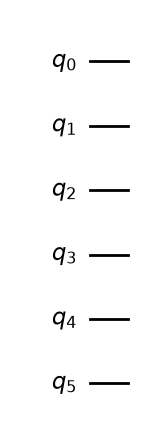

In [14]:
#Chapter 2:

special_qc = QuantumCircuit(6)

special_qc.draw("mpl")

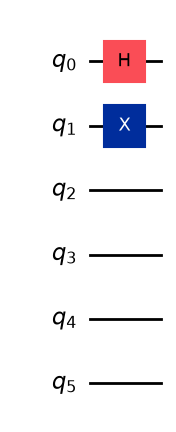

In [15]:
special_qc.h(0)
special_qc.x(1)

special_qc.draw("mpl")

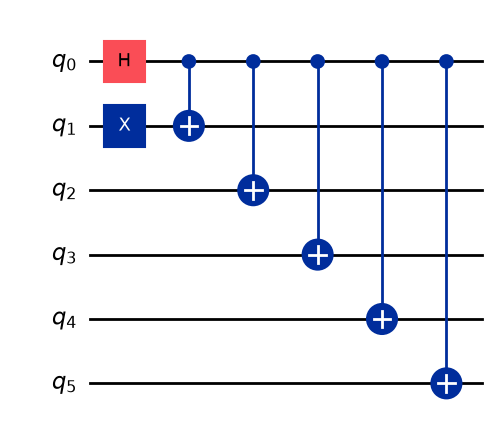

In [16]:
# Step 3: CNOT chain — entangle all qubits with qubit 0
# Loop over qubits 1 through 5 and apply CNOT with qubit 0 as control

for i in range(1,6):
    special_qc.cx(0,i)


special_qc.draw('mpl')

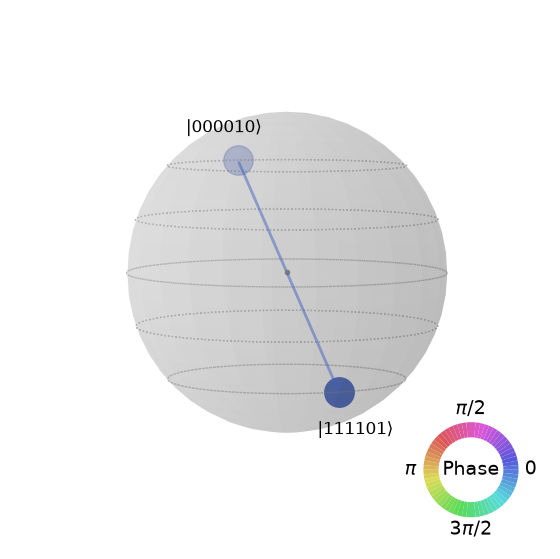

In [17]:
sv = Statevector(special_qc)
array_to_latex(sv, max_size=64)
plot_state_qsphere(sv)

In [20]:
grade_lab0_ex4(sv)
check_progress("lab0")

Grading your answer. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-16 07:47:23,551: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Congratulations! 🎉 Your answer is correct. Fidelity: 1.000000
You just created the Qiskit logo!

Looking forward to the QGSS main event starting in a week? Take this course:
https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today
You scored 1 on this exercise.
Fetching your progress. Please wait...



qiskit_runtime_service.__init__:WARNING:2026-07-16 07:47:29,805: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


📊 Your progress

Lab "lab0" — 4/4 passed, score 4.0
  ✅ ex1 — score 1.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0


In [ ]:
check_progress("Lab0")